In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
leads=pd.read_csv("leads.csv")
funnel=pd.read_csv("funnel.csv")
cost=pd.read_csv("cost.csv")

In [5]:
df=leads.merge(funnel, on="Lead_ID")
print(df.head(10))

  Lead_ID   Lead_Source       City Course_Interest        Date Counselling  \
0  L00001      LinkedIn     Mumbai  Data Analytics  17-04-2025         Yes   
1  L00002     Instagram     Mumbai  Data Analytics  22-01-2025         Yes   
2  L00003  Campus Drive       Pune    Data Science  02-02-2025         Yes   
3  L00004      LinkedIn       Pune  Data Analytics  03-03-2025         Yes   
4  L00005      LinkedIn    Chennai    Data Science  03-01-2025          No   
5  L00006       Website  Bangalore  Data Analytics  18-01-2025          No   
6  L00007  Campus Drive       Pune           AI/ML  09-01-2025         Yes   
7  L00008     Instagram     Mumbai  Data Analytics  04-02-2025          No   
8  L00009     Instagram    Chennai           AI/ML  06-01-2025         Yes   
9  L00010       Website       Pune           AI/ML  03-03-2025          No   

  Application Enrolled  Test_Score  
0         Yes      Yes        81.0  
1          No       No         NaN  
2         Yes       No        

In [16]:
print(cost.columns)
print(df.columns)

Index(['Channel', 'Monthly_Cost'], dtype='object')
Index(['Lead_ID', 'Lead_Source', 'City', 'Course_Interest', 'Date',
       'Counselling', 'Application', 'Enrolled', 'Test_Score'],
      dtype='object')


In [17]:
lead = df.groupby("Lead_Source")["Lead_ID"].nunique()

application = df[df["Application"]=="Yes"].groupby("Lead_Source")["Lead_ID"].count()

enrollments = df[df["Enrolled"]=="Yes"].groupby("Lead_Source")["Lead_ID"].count()

In [19]:
analysis = pd.DataFrame({
    "Leads": lead,
    "Applications": application,
    "Enrollments": enrollments
})

analysis["Conversion_Rate"] = (analysis["Enrollments"] / analysis["Leads"] * 100).round(2)
print(analysis)

              Leads  Applications  Enrollments  Conversion_Rate
Lead_Source                                                    
Campus Drive   2216           796          317            14.31
Instagram      5280          2098          922            17.46
LinkedIn       3811          1842         1278            33.53
Website        3693          1545          849            22.99


In [20]:
analysis = analysis.reset_index()

In [21]:
analysis = analysis.merge(cost, left_on="Lead_Source", right_on="Channel")

In [28]:
analysis["Cost_per_Lead"] = (analysis["Monthly_Cost"] / analysis["Leads"]).round(2)
analysis["Cost_per_Enrollment"] = (analysis["Monthly_Cost"] / analysis["Enrollments"]).round(2)

In [29]:
print(analysis)

    Lead_Source  Leads  Applications  Enrollments  Conversion_Rate  \
0  Campus Drive   2216           796          317            14.31   
1     Instagram   5280          2098          922            17.46   
2      LinkedIn   3811          1842         1278            33.53   
3       Website   3693          1545          849            22.99   

        Channel  Monthly_Cost  Cost_per_Enrollment  Cost_per_Lead  
0  Campus Drive        554000              1747.63          250.0  
1     Instagram       1584000              1718.00          300.0  
2      LinkedIn       1219520               954.24          320.0  
3       Website        923250              1087.46          250.0  


In [30]:
quality = df[df["Test_Score"].notna()].groupby("Lead_Source")["Test_Score"].mean().round(2).reset_index()

quality.columns = ["Lead_Source", "Avg_Test_Score"]

print(quality)

    Lead_Source  Avg_Test_Score
0  Campus Drive           61.11
1     Instagram           66.57
2      LinkedIn           78.84
3       Website           72.50


In [32]:
course_demand = df.groupby(["Lead_Source", "Course_Interest"])["Lead_ID"].count().reset_index()

course_demand.columns = ["Lead_Source", "Course", "Count"]
print(course_demand)

     Lead_Source          Course  Count
0   Campus Drive           AI/ML    751
1   Campus Drive  Data Analytics    734
2   Campus Drive    Data Science    731
3      Instagram           AI/ML   1807
4      Instagram  Data Analytics   1703
5      Instagram    Data Science   1770
6       LinkedIn           AI/ML   1272
7       LinkedIn  Data Analytics   1266
8       LinkedIn    Data Science   1273
9        Website           AI/ML   1251
10       Website  Data Analytics   1234
11       Website    Data Science   1208


In [34]:
city_analysis = df.groupby(["City", "Lead_Source"])["Lead_ID"].count().reset_index()
print(city_analysis)

         City   Lead_Source  Lead_ID
0   Bangalore  Campus Drive      346
1   Bangalore     Instagram      870
2   Bangalore      LinkedIn      599
3   Bangalore       Website      671
4     Chennai  Campus Drive      375
5     Chennai     Instagram      928
6     Chennai      LinkedIn      657
7     Chennai       Website      538
8       Delhi  Campus Drive      364
9       Delhi     Instagram      849
10      Delhi      LinkedIn      650
11      Delhi       Website      655
12  Hyderabad  Campus Drive      360
13  Hyderabad     Instagram      876
14  Hyderabad      LinkedIn      637
15  Hyderabad       Website      628
16     Mumbai  Campus Drive      384
17     Mumbai     Instagram      901
18     Mumbai      LinkedIn      634
19     Mumbai       Website      626
20       Pune  Campus Drive      387
21       Pune     Instagram      856
22       Pune      LinkedIn      634
23       Pune       Website      575


In [36]:
df["Date"] = pd.to_datetime(df["Date"],dayfirst=True)

trend = df.groupby(df["Date"].dt.to_period("M"))["Lead_ID"].count()
print(trend)

Date
2025-01    3901
2025-02    3468
2025-03    3891
2025-04    3740
Freq: M, Name: Lead_ID, dtype: int64


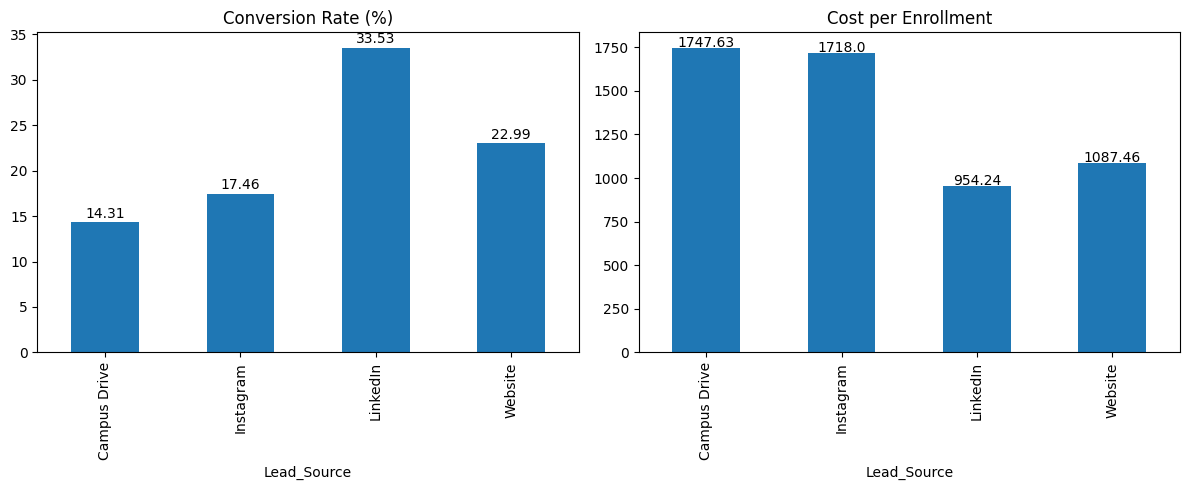

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
analysis.plot(x="Lead_Source", y="Conversion_Rate", kind="bar", ax=ax1, legend=False)
ax1.set_title("Conversion Rate (%)")

for i, v in enumerate(analysis["Conversion_Rate"]):
    ax1.text(i, v + 0.5, str(v), ha='center')

ax2 = axes[1]
analysis.plot(x="Lead_Source", y="Cost_per_Enrollment", kind="bar", ax=ax2, legend=False)
ax2.set_title("Cost per Enrollment")

for i, v in enumerate(analysis["Cost_per_Enrollment"]):
    ax2.text(i, v + 5, str(v), ha='center')

plt.tight_layout()
plt.show()

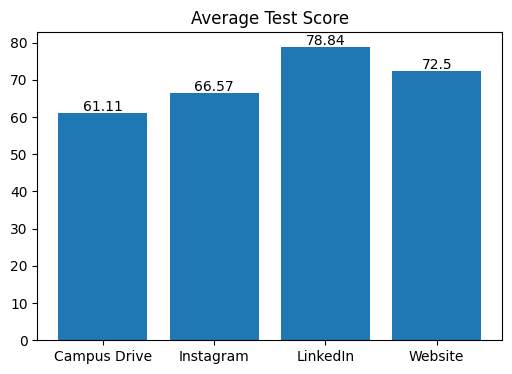

In [43]:
plt.figure(figsize=(6,4))

plt.bar(quality["Lead_Source"], quality["Avg_Test_Score"])
plt.title("Average Test Score")

for i, v in enumerate(quality["Avg_Test_Score"]):
    plt.text(i, v + 0.5, str(v), ha='center')

plt.show()

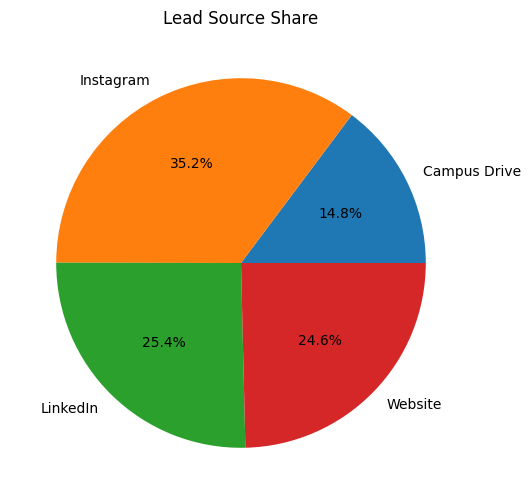

In [45]:
lead_share = analysis.set_index("Lead_Source")["Leads"]

plt.figure(figsize=(6,6))

plt.pie(lead_share, labels=lead_share.index, autopct='%1.1f%%')
plt.title("Lead Source Share")

plt.show()

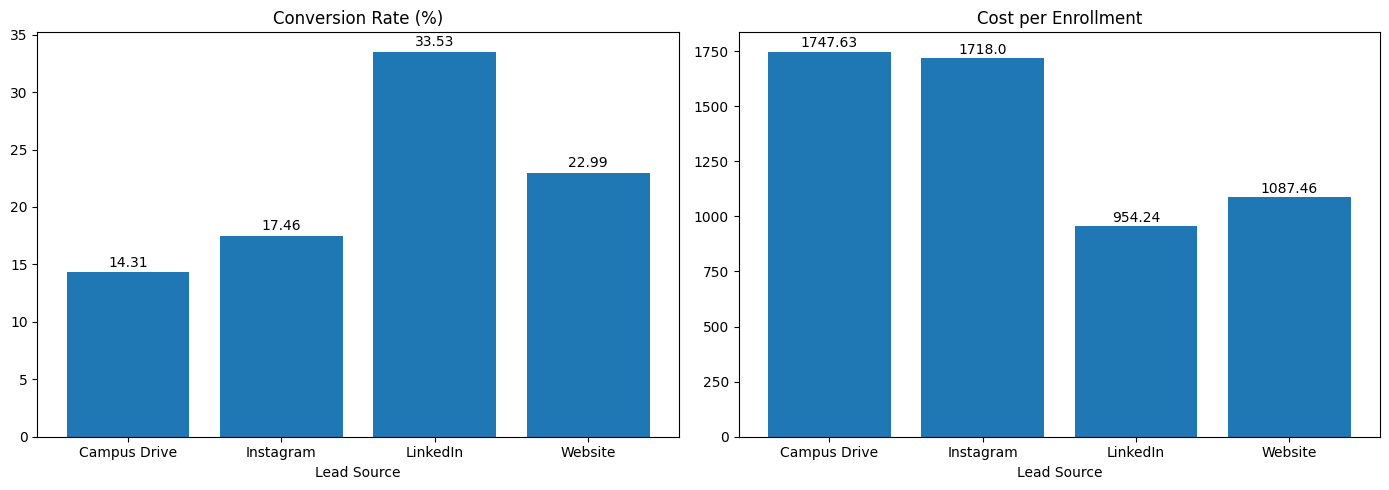

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(analysis["Lead_Source"], analysis["Conversion_Rate"])
axes[0].set_title("Conversion Rate (%)")
axes[0].set_xlabel("Lead Source")

for i, v in enumerate(analysis["Conversion_Rate"]):
    axes[0].text(i, v + 0.5, str(v), ha='center')

axes[1].bar(analysis["Lead_Source"], analysis["Cost_per_Enrollment"])
axes[1].set_title("Cost per Enrollment")
axes[1].set_xlabel("Lead Source")

for i, v in enumerate(analysis["Cost_per_Enrollment"]):
    axes[1].text(i, v + 20, str(v), ha='center')

plt.tight_layout()
plt.show()

In [52]:
corr = analysis[["Leads", "Enrollments", "Conversion_Rate", "Monthly_Cost", "Cost_per_Enrollment"]].corr()

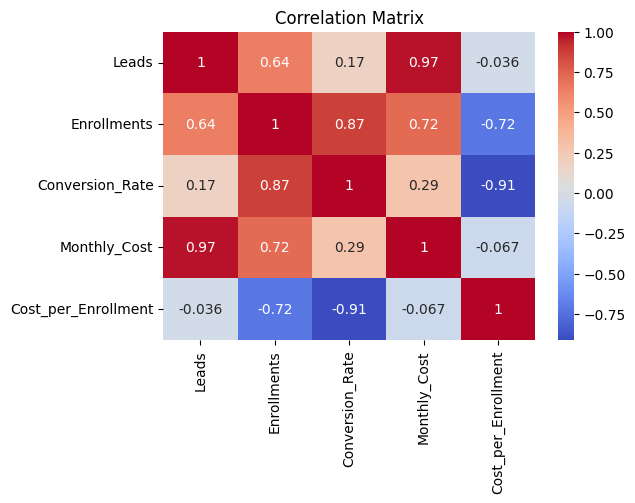

In [51]:
plt.figure(figsize=(6,4))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

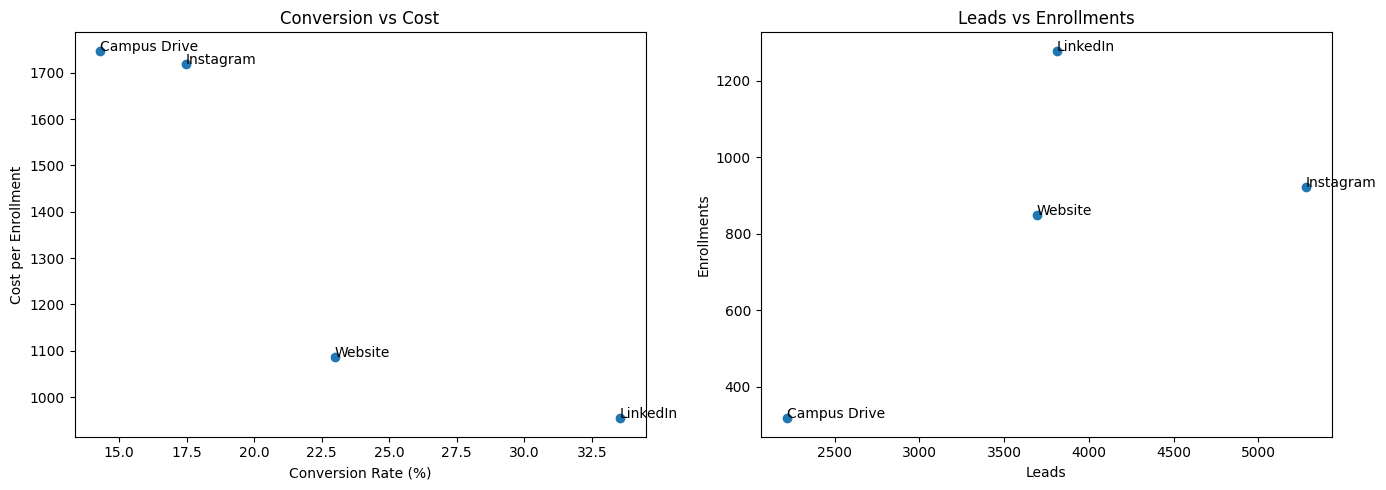

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 🔹 Conversion vs Cost
axes[0].scatter(analysis["Conversion_Rate"], analysis["Cost_per_Enrollment"])
axes[0].set_title("Conversion vs Cost")
axes[0].set_xlabel("Conversion Rate (%)")
axes[0].set_ylabel("Cost per Enrollment")

for i, txt in enumerate(analysis["Lead_Source"]):
    axes[0].text(analysis["Conversion_Rate"][i], analysis["Cost_per_Enrollment"][i], txt)

# 🔹 Leads vs Enrollments
axes[1].scatter(analysis["Leads"], analysis["Enrollments"])
axes[1].set_title("Leads vs Enrollments")
axes[1].set_xlabel("Leads")
axes[1].set_ylabel("Enrollments")

for i, txt in enumerate(analysis["Lead_Source"]):
    axes[1].text(analysis["Leads"][i], analysis["Enrollments"][i], txt)

plt.tight_layout()
plt.show()

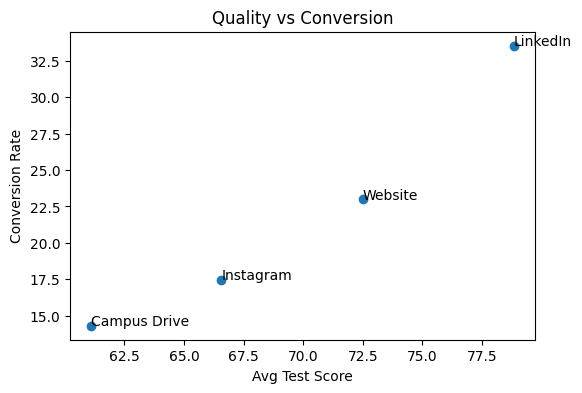

In [55]:
merged = analysis.merge(quality, on="Lead_Source")

plt.figure(figsize=(6,4))

plt.scatter(merged["Avg_Test_Score"], merged["Conversion_Rate"])

for i, txt in enumerate(merged["Lead_Source"]):
    plt.text(merged["Avg_Test_Score"][i], merged["Conversion_Rate"][i], txt)

plt.xlabel("Avg Test Score")
plt.ylabel("Conversion Rate")
plt.title("Quality vs Conversion")

plt.show()